<a href="https://colab.research.google.com/github/Ayushsan1/Pytorch-Implementation-and-Foundation/blob/main/02_NN_classification_with_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##02 NN Classification with PyTorch

Classification is probelm of predicting whether something is one or Another and they can
can also be Multiple class classified.

###1. Make a Simple Data (Custom Dataset)
Note: The data we working with here is often referred to as toy dataset , that is small enough to experiment but sizeable enough to learn and practice fundamentals.

In [2]:
import sklearn
from sklearn.datasets import make_circles # used to generate Toy Dataset

In [3]:
# Make 100 samples
n_samples = 1000
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

In [4]:
len(X), len(y)

(1000, 1000)

In [5]:
print(f"first five samples of X: {X[:5]}")
print(f"First five samples of y: {y[:5]}")
#would show 2 features of X which relates to 1 label of Y ( and here it is Binary as  only 0 and 1 is the label)

first five samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First five samples of y: [1 1 1 1 0]


In [6]:
# Make DataFrame of circle Data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0], #features of X left side (0th index)
                       "X2" : X[:, 1], #features of X in right (1st index)
                       "label" :y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


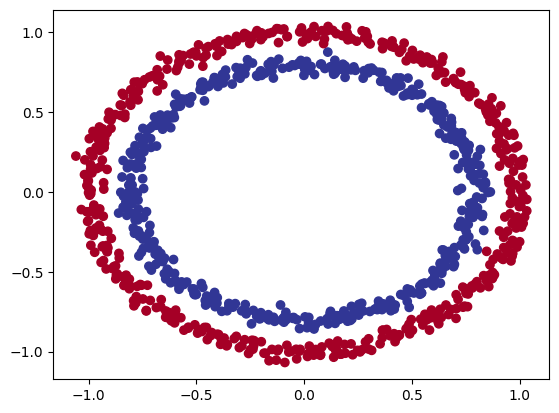

In [7]:
# Lets visualise to learn pattern
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap =plt.cm.RdYlBu)

####Check Input and Output Shapes

In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
X_sample =X[0]
y_sample = y[0]

print(f"values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [10]:
import torch
torch.__version__

'2.11.0+cpu'

In [11]:
X.dtype

dtype('float64')

In [12]:
#turning data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

###Splitting data into training and testing splits

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    train_size=0.8,
                                                    random_state=42)

In [14]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

### Lets Build a Model

Building a Model to classify our blue and red dots

To do so we need to:
1. Setup Device agnostic code
2. Construct a model ( by subclassing 'nn.Module')
3. Create a training and test loop

In [15]:
import torch
from torch import nn

#device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

#### Lets create a Model that:

1. Subclasses 'nn.Module'
2. Create 2 'nn.Linear()' layers that are capable of handling the shapes of our data
3. Defines a 'forward()' method that outline the forward pass of the model_selection
4. Instantiate an instance of our model class and send it to the target

In [16]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    #create 2 nn.linear layers
    self.layer_1 = nn.Linear(in_features=2,
                             out_features=5) # 2 input features --> 5 output feature
    self.layer_2 = nn.Linear(in_features =5,
                             out_features=1) # we kept here in_features =5 as because first layer had same inner dimension feature

  def forward(self, x):
    return self.layer_2(self.layer_1(x)) #x --> layer_1 --> layer_2 --> output

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
#Lets the replicate the model above with nn.sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device) # removes the hustle to create a forward pass but still above is required when building complex layers

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
#Make some prdctions with the model
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1852, -0.2392],
                      [-0.1608, -0.6255],
                      [ 0.4973,  0.2486],
                      [ 0.5156,  0.6625],
                      [ 0.3380, -0.1179]])),
             ('0.bias', tensor([-0.2665,  0.4153,  0.0652,  0.1156,  0.6825])),
             ('1.weight',
              tensor([[-0.2048,  0.0972, -0.2508, -0.3796, -0.2721]])),
             ('1.bias', tensor([0.1173]))])

In [19]:
#Make Prediction before training
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
  print(f"Length of Predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
  print(f"length of test samples: {len(X_test)}, Shape: {X_test.shape}")
  print(f"First 10 predictions: {untrained_preds[:10]}")
  print(f"First 10 test samples: {y_test[:10]}")


Length of Predictions: 200, Shape: torch.Size([200, 1])
length of test samples: 200, Shape: torch.Size([200, 2])
First 10 predictions: tensor([[-0.0593],
        [-0.3227],
        [ 0.3861],
        [-0.1845],
        [-0.0029],
        [-0.1607],
        [-0.5940],
        [-0.5571],
        [ 0.4019],
        [-0.3447]])
First 10 test samples: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


## Setup Loss Function and Optimizer

Which loss funtion or Optimizer should we use ?

It is Problem Specific:
1. for Regression - we might want MAE or MSE
2. For classification - we might want BCE or CE (Binary Cross Entropy)

And for Optimizer , two of the most common and useful are SGD and Adam, however PyTorch has many built in options.
for Loss function we would use 'torch.nn.BCEWithLogitsLoss' - as Binary Cross Entropy for Classification

In [20]:
#Setup loss functions
#loss_fn = nn.BCELoss #requires input to have gone through the sigmoid activation function prior to input to BCELoss
# this means we use below code to reduce the effort to do this:
# nn.sequential(
#     nn.sigmoid(),
#     nn.BCELoss()
# )
loss_fn = nn.BCEWithLogitsLoss() #BCEWithLogitLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [21]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1852, -0.2392],
                      [-0.1608, -0.6255],
                      [ 0.4973,  0.2486],
                      [ 0.5156,  0.6625],
                      [ 0.3380, -0.1179]])),
             ('0.bias', tensor([-0.2665,  0.4153,  0.0652,  0.1156,  0.6825])),
             ('1.weight',
              tensor([[-0.2048,  0.0972, -0.2508, -0.3796, -0.2721]])),
             ('1.bias', tensor([0.1173]))])

In [22]:
#Calculate the Accuracy - out of 100, what percentage does our model get correct?
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item
  acc = (correct/len(y_pred))*100
  return acc

#3. Training the Model

To Train our model, we need to perform training loop:

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (GD)

Our model raw output are going to be called as **Logits**

we can convert these **logits** into Prediction Probabilities by passing them to some
kind of activation func ( e.g sigmoid for binary, softmax for multiclass)

Then we can convert our model probabilities to prediction label by either rounding them or taking argmax()

In [23]:
# View the first 5 outputs of Forward pass on test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0593],
        [-0.3227],
        [ 0.3861],
        [-0.1845],
        [-0.0029]])

In [24]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

####Since we need our y_logits output to be in same format as "tensor([1., 0., 1., 0., 1.])" for that we would need rounding off technique to implemented to get our models raw output(logits) into such a form, we can use the **sigmoid** activation function


In [25]:
y_pred_prob = torch.sigmoid(y_logits)
y_pred_prob
#These somehow now in some kind of consistency and they are now in form of prediction probabilities

tensor([[0.4852],
        [0.4200],
        [0.5954],
        [0.4540],
        [0.4993]])

so lets define rule :
* if y_pred_prob >= 0.5 then y=1 (means class 1)
* if y_pred_prob < 0.5 then y=0 (means class 0)

In [26]:
y_preds = torch.round(y_pred_prob)

# In Full ( logits --> pred prob --> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

#check for Equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 0.])

## Building and Testing Loops

In [27]:
torch.manual_seed(42)

epochs =1000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

for epoch in range(epochs):
  model_0.train()
  #Forward Pass
  y_logits = model_0(X_train.to(device)).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # sigmoid converts logits in prdction probabbilities

  #Calculate the loss
  # loss = loss_fn(torch.sigmoid(y_logits),
  #                y_train)
  loss = loss_fn(y_logits,
                 y_train)
  acc = accuracy_fn(y_true = y_train,
                    y_pred = y_pred)
  #Optimizer zero grad
  optimizer.zero_grad()

  #loss backward
  loss.backward()

  #optimizer step
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    #1. forward pass
    test_logits = model_0(X_test.to(device)).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    #test loss calculation
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

    # print what happening
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.71106 | Accuracy: 49.50% | Test Loss: 0.69822 | Test Accuracy: 52.00%
Epoch: 10 | Loss: 0.70635 | Accuracy: 49.50% | Test Loss: 0.69557 | Test Accuracy: 52.00%
Epoch: 20 | Loss: 0.70311 | Accuracy: 49.38% | Test Loss: 0.69404 | Test Accuracy: 51.00%
Epoch: 30 | Loss: 0.70081 | Accuracy: 49.50% | Test Loss: 0.69317 | Test Accuracy: 52.00%
Epoch: 40 | Loss: 0.69912 | Accuracy: 50.00% | Test Loss: 0.69271 | Test Accuracy: 51.00%
Epoch: 50 | Loss: 0.69788 | Accuracy: 49.62% | Test Loss: 0.69250 | Test Accuracy: 50.50%
Epoch: 60 | Loss: 0.69693 | Accuracy: 49.50% | Test Loss: 0.69246 | Test Accuracy: 51.00%
Epoch: 70 | Loss: 0.69621 | Accuracy: 49.62% | Test Loss: 0.69251 | Test Accuracy: 51.00%
Epoch: 80 | Loss: 0.69566 | Accuracy: 49.62% | Test Loss: 0.69263 | Test Accuracy: 51.00%
Epoch: 90 | Loss: 0.69522 | Accuracy: 50.25% | Test Loss: 0.69278 | Test Accuracy: 51.00%
Epoch: 100 | Loss: 0.69488 | Accuracy: 50.38% | Test Loss: 0.69296 | Test Accuracy: 49.50%
Epoch: 110

### Make Predction and Evaluate the model

as from metrics it looks like our model is'nt learning anything...
so to inspect it lets make some predictions and make them visual

In [28]:
import requests
from pathlib import Path

#Download helper function from PyTorch Repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request =requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


Text(0.5, 1.0, 'predictions on train data')

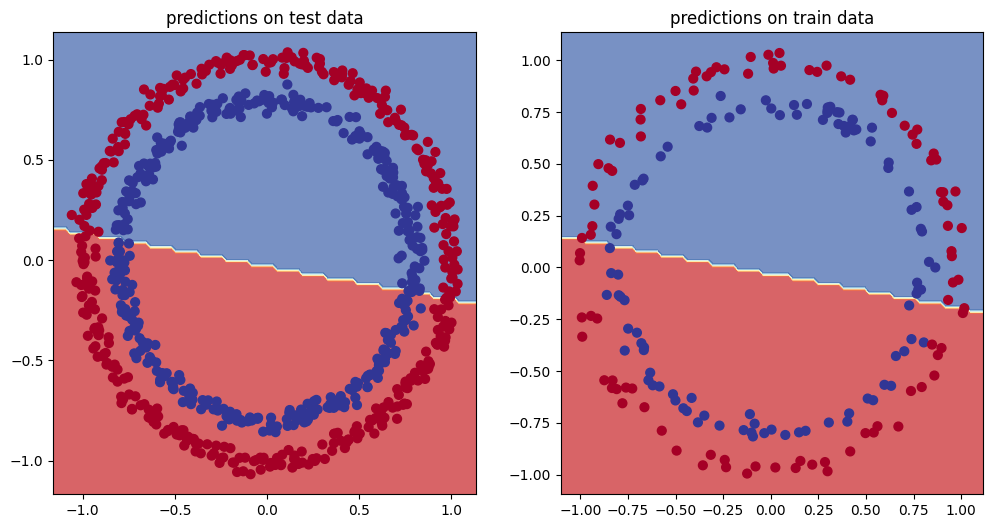

In [29]:
#Plot decision boundary of the model
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.title("predictions on test data")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_0, X_test, y_test)
plt.title("predictions on train data")

### Improving a model (from a model perspective)
 * Add more layer - give the model more chnace to learn about pattern in data.
 * Add more hidden units
 * Changing the Activation function
 * changing the LR ( learning rate)
 * change the loss function

In [30]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0488, -0.2487],
                      [-0.1836, -0.6101],
                      [ 0.4593,  0.2130],
                      [ 0.4075,  0.6291],
                      [ 0.1965, -0.1333]])),
             ('0.bias', tensor([-0.2592,  0.4196,  0.0616,  0.1165,  0.6890])),
             ('1.weight',
              tensor([[-0.1036, -0.0470,  0.1001, -0.0461, -0.1057]])),
             ('1.bias', tensor([0.0667]))])

In [31]:
#Adding more hidden units , increase no of layers and increase number epochs...
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    #create 2 nn.linear layers
    self.layer_1 = nn.Linear(in_features=2,
                             out_features=10) # 2 input features --> 10 output feature
    self.layer_2 = nn.Linear(in_features =10,
                             out_features=10) # 10 input features --> 10 output feature
    self.layer_3 = nn.Linear(in_features =10,
                             out_features=1) # 10 input features --> 1 output feature

  def forward(self, x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x))) #this way writing opertions leverages speed ups

model_1 = CircleModelV1().to(device)

model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [32]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()
#Create a optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [33]:
# write a training and evaluation loop for model_1
torch.manual_seed(42)

# Train for longer
epochs =1000

#put data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()
  #Forward Pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #Calculate the loss /Accuracy
  loss = loss_fn(y_logits,
                 y_train)
  acc = accuracy_fn(y_true = y_train,
                    y_pred = y_pred)

  #Optimizer zero grad
  optimizer.zero_grad()

  #loss backward pass
  loss.backward()

  #Optimize step
  optimizer.step()

  #Testing
  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  #print out what happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 100 | Loss: 0.69305 | Accuracy: 50.38% | Test Loss: 0.69379 | Test Accuracy: 48.00%
Epoch: 200 | Loss: 0.69299 | Accuracy: 51.12% | Test Loss: 0.69437 | Test Accuracy: 46.00%
Epoch: 300 | Loss: 0.69298 | Accuracy: 51.62% | Test Loss: 0.69458 | Test Accuracy: 45.00%
Epoch: 400 | Loss: 0.69298 | Accuracy: 51.12% | Test Loss: 0.69465 | Test Accuracy: 46.00%
Epoch: 500 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69467 | Test Accuracy: 46.00%
Epoch: 600 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 700 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 800 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 900 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%


Text(0.5, 1.0, 'predictions on train data')

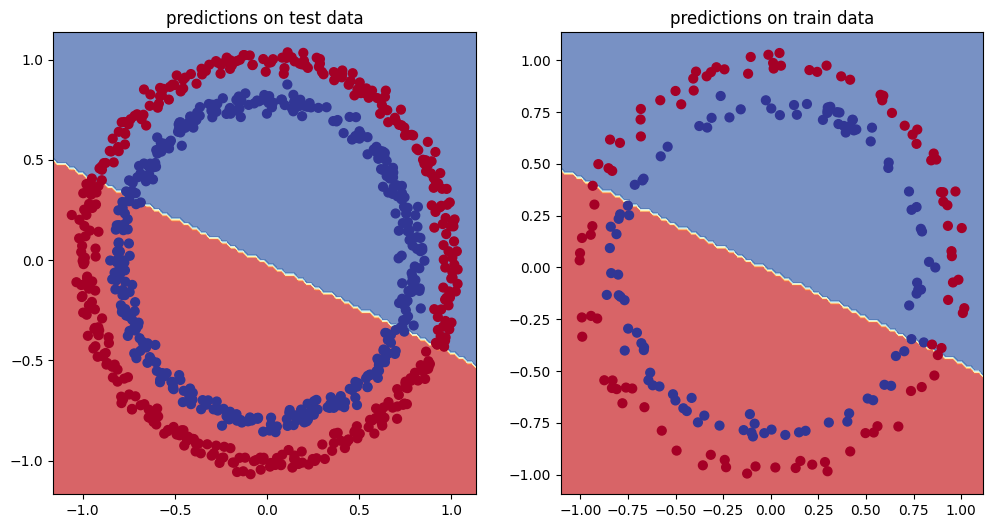

In [34]:
#Lets Plot the decision boundary
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.title("predictions on test data")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_1, X_test, y_test)
plt.title("predictions on train data")

Our model is still drawing a straight line b/w the red and blue dots... means it can do linear data modeling.. like we did in the PyTorch Fundamentals sections

### Preparing data to see if our model can model straight line ?


In [35]:
#Creating Data
weight = 0.7
bias = 0.3
start = 0
end =1
step = 0.01

#Create the Data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

X_regression[:10], y_regression[:10]

#Check the Data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [36]:
#Spliting data into training and testing set
train_split = int(0.8*len(X_regression))
X_train_reg, y_train_reg = X_regression[:train_split], y_regression[:train_split]
X_test_reg, y_test_reg = X_regression[train_split:], y_regression[train_split:]

len(X_train_reg), len(y_train_reg), len(X_test_reg), len(y_test_reg)

(80, 80, 20, 20)

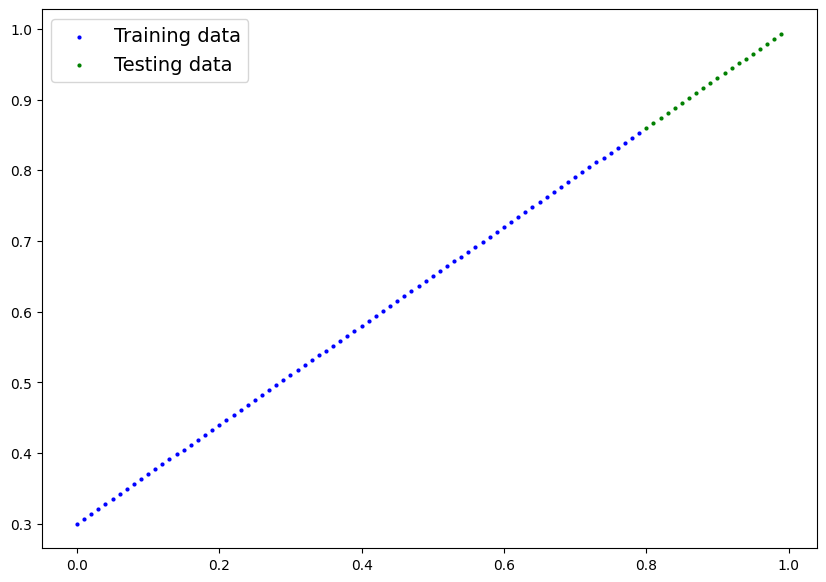

In [37]:
plot_predictions(train_data= X_train_reg, train_labels = y_train_reg,
                 test_data=X_test_reg,
                 test_labels=y_test_reg,
                 predictions=None)
#

### Now Adjusting model_1 to fit staright line

In [38]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [39]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)

In [40]:
##Training the Model (model_2)
torch.manual_seed(42)

epochs = 1000

#put data to target device
X_train_reg, y_train_reg = X_train_reg.to(device), y_train_reg.to(device)
X_test_reg, y_test_reg = X_test_reg.to(device), y_test_reg.to(device)

for epoch in range(epochs):
  model_2.train()
  #Forward Pass
  y_pred = model_2(X_train_reg)
  #Calculate loss
  loss = loss_fn(y_pred, y_train_reg)
  #optimizer zero grad
  optimizer.zero_grad()
  #loss backward
  loss.backward()
  #optimizer step
  optimizer.step()

  #Testing
  model_2.eval()
  with torch.inference_mode():
    #forward pass
    test_pred = model_2(X_test_reg)
    #calculate the loss
    test_loss = loss_fn(test_pred, y_test_reg)

  if epoch % 100 ==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")


Epoch: 0 | Loss: 0.75986 | Test Loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test Loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test Loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test Loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test Loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test Loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test Loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test Loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test Loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test Loss: 0.00360


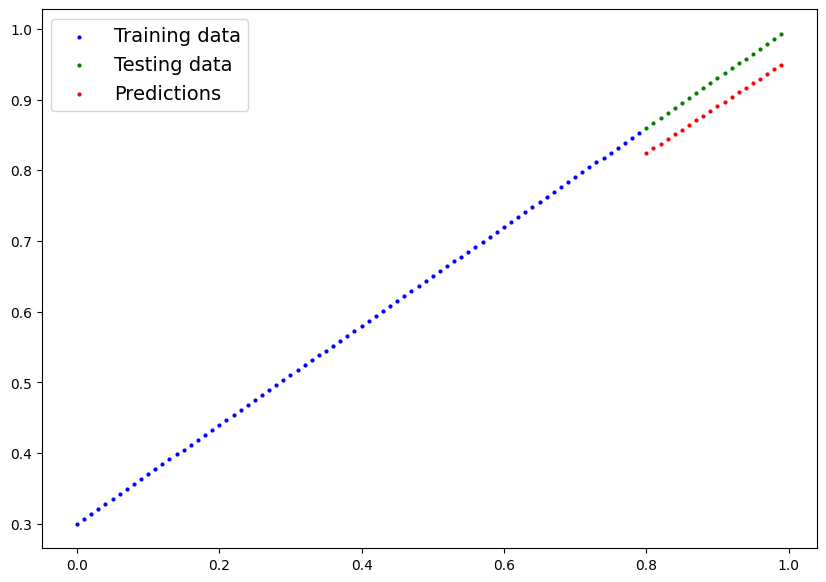

In [41]:
## Turn on Evaluation mode
model_2.eval()

#make predictions
with torch.inference_mode():
  y_preds = model_2(X_test_reg)

#plot the data and predictions with data on the CPU as matplotlib cannot run on GPU

plot_predictions(train_data= X_train_reg.cpu(), train_labels = y_train_reg.cpu(),
                 test_data=X_test_reg.cpu(),
                 test_labels=y_test_reg.cpu(),
                 predictions = y_preds.cpu());

### NON-LINEARITY
"What pattern could you draw if you were given an infinite amount of a straight and non-straight lines"

#### Recreating the non-linear data (red and blue circles)

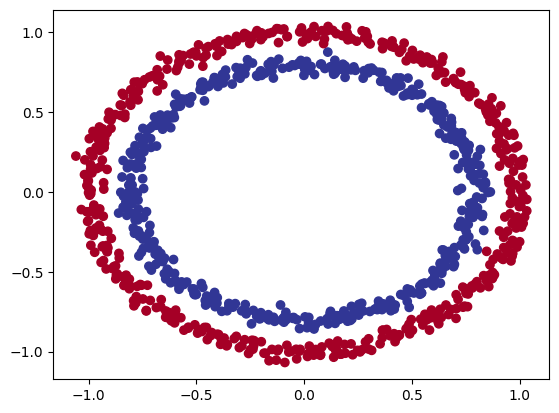

In [42]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [43]:
# Convert data to tensor and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

#turn data in tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### Building a model with Non - Linearity


 #### we would be using PyTorch Non-Linear activation functions (ready-made) and one of the most common one is Rectified linear Unit (ReLU) used as "torch.nn.ReLU()"

In [44]:
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()
    #Can also put sigmoid in the model
    #this would mean you don't need to use it on the predictions
    #self.sigmoid = nn.sigmoid()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.layer_1(x))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


###Now as we have got our model ready, lets create binary classification:
* Loss Function
* Optimizer

In [45]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)
#

##Training a model with Non-Linearity

In [47]:
torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
print(X_train.shape, X_train.dtype)
# print(X[0:10,0:10])

for epoch in range(epochs):
  #Forward pass
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  #Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
  #optimizer zero grad
  optimizer.zero_grad()

  #loss backward
  loss.backward()

  #optimizer step
  optimizer.step()

  #Testing
  model_3.eval()
  with torch.inference_mode():
    #forward pass
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    #calculate the loss and accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

torch.Size([800, 2]) torch.float32
Epoch: 0 | Loss: 0.69833 | Accuracy: 50.00% | Test Loss: 0.69863 | Test Accuracy: 49.00%
Epoch: 100 | Loss: 0.69289 | Accuracy: 50.88% | Test Loss: 0.69411 | Test Accuracy: 47.00%
Epoch: 200 | Loss: 0.69015 | Accuracy: 53.37% | Test Loss: 0.69141 | Test Accuracy: 50.00%
Epoch: 300 | Loss: 0.68762 | Accuracy: 56.62% | Test Loss: 0.68828 | Test Accuracy: 55.00%
Epoch: 400 | Loss: 0.68469 | Accuracy: 60.00% | Test Loss: 0.68469 | Test Accuracy: 61.00%
Epoch: 500 | Loss: 0.67985 | Accuracy: 56.00% | Test Loss: 0.67890 | Test Accuracy: 60.50%
Epoch: 600 | Loss: 0.67280 | Accuracy: 56.00% | Test Loss: 0.67176 | Test Accuracy: 60.50%
Epoch: 700 | Loss: 0.66304 | Accuracy: 64.50% | Test Loss: 0.66452 | Test Accuracy: 65.00%
Epoch: 800 | Loss: 0.64710 | Accuracy: 74.12% | Test Loss: 0.65300 | Test Accuracy: 71.50%
Epoch: 900 | Loss: 0.62182 | Accuracy: 81.62% | Test Loss: 0.63241 | Test Accuracy: 78.00%


Text(0.5, 1.0, 'predictions on train data')

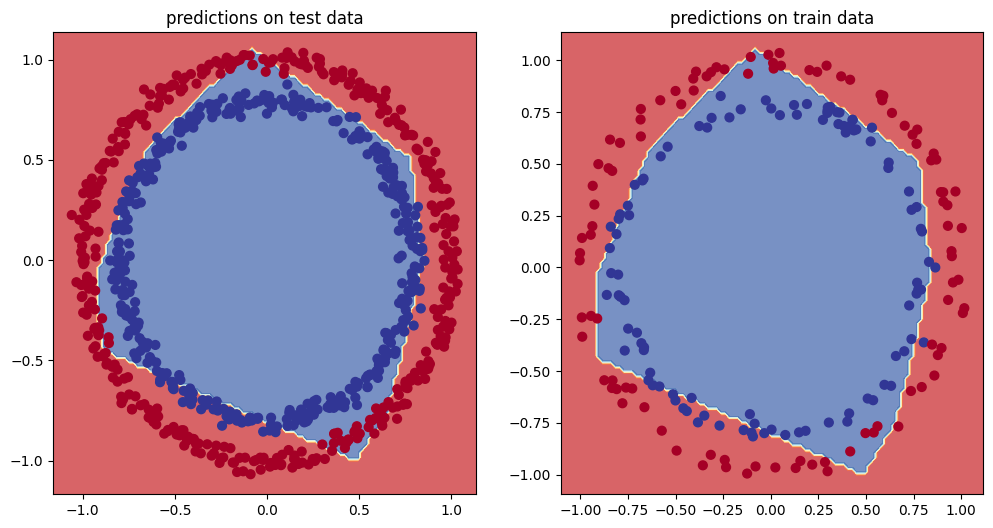

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.title("predictions on test data")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_3, X_test, y_test)
plt.title("predictions on train data")